## Run with command below for Mono AQ and AL using config in experiments/recurrence/config:
```
DxGGenerator --recurrence-test -i ./sample_inputs/single_loc_location_based/input_recurrence_test.yml --tl 2 -g "||||NY1||KTHFIMG,x||||||FNCMYRIPRPCRA|1"
DxGGenerator --recurrence-test -i ./sample_inputs/single_loc_location_based/input_recurrence_test.yml --tl 6 -g "||||NY1||KTHFIMG,x||||||FNCMYRIPRPCRA|1"
```

## Mono AQ

In [1]:
import pandas as pd 
import numpy as np
import os

parasitaemia = pd.read_csv('/Users/ktt/CLionProjects/malasim/cmake-build-release/bin/2_||||NY1||KTHFIMG,x||||||FNCMYRIPRPCRA|1_parasitaemia.csv')
# remap recruitment number to a unique identifier
# 0 : non-recrudescence
# 1 : recrudescence without symptoms
# 2 : recrudescence with symptoms
parasitaemia['recrudescence'] = parasitaemia['recrudescence'].map({
    0: 'non-recrudescence',
    1: 'recrudescence without symptoms',
    2: 'recrudescence with symptoms'
})
parasitaemia['parasitaemia'] = np.power(10, parasitaemia['parasitaemia'])
# parasitaemia['time'] = parasitaemia['time'] -1

# Reprocess the data to update recrudescence types
# For individuals who have recrudescence at a later time, change their initial recrudescence type from 'non-recrudescence' to the correct type

# Sort the data by individual and time to ensure proper sequence of time points
parasitaemia = parasitaemia.sort_values(by=['individual', 'time'])

FORCE_CREATE_PROCESSED_CSV = True  # Set to True to force re-creation of the processed CSV
# Check if processed csv exists, if not create it
processed_csv_path = '/Users/ktt/CLionProjects/malasim/cmake-build-release/bin/2_||||NY1||KTHFIMG,x||||||FNCMYRIPRPCRA|1_parasitaemia_processed.csv'

if FORCE_CREATE_PROCESSED_CSV or not os.path.exists(processed_csv_path):
    print(f"Creating new processed data at {processed_csv_path}")
    # For each individual, check if they eventually develop recrudescence and update the recrudescence type
    for individual in parasitaemia['individual'].unique():
        individual_data = parasitaemia[parasitaemia['individual'] == individual]
        if 'non-recrudescence' in individual_data['recrudescence'].values:
            # Check if recrudescence occurs later
            recrudescence_types = individual_data['recrudescence'].unique()
            if len(recrudescence_types) > 1:
                # Get the first recrudescence type other than 'non-recrudescence'
                first_recrud = individual_data[individual_data['recrudescence'] != 'non-recrudescence']['recrudescence'].iloc[0]
                # Update the recrudescence type for the initial period
                parasitaemia.loc[parasitaemia['individual'] == individual, 'recrudescence'] = first_recrud

    parasitaemia.to_csv(processed_csv_path, index=False)
    print(f"Processed parasitaemia data saved to {processed_csv_path}")
    processed_parasitaemia = pd.read_csv(processed_csv_path)
else:
    processed_parasitaemia = pd.read_csv(processed_csv_path)
    print(f"Processed parasitaemia data loaded from {processed_csv_path}")



Creating new processed data at /Users/ktt/CLionProjects/malasim/cmake-build-release/bin/2_||||NY1||KTHFIMG,x||||||FNCMYRIPRPCRA|1_parasitaemia_processed.csv
Processed parasitaemia data saved to /Users/ktt/CLionProjects/malasim/cmake-build-release/bin/2_||||NY1||KTHFIMG,x||||||FNCMYRIPRPCRA|1_parasitaemia_processed.csv


In [2]:
# parasitaemia["time"] = processed_parasitaemia["time"] - 3655
processed_parasitaemia["time"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])

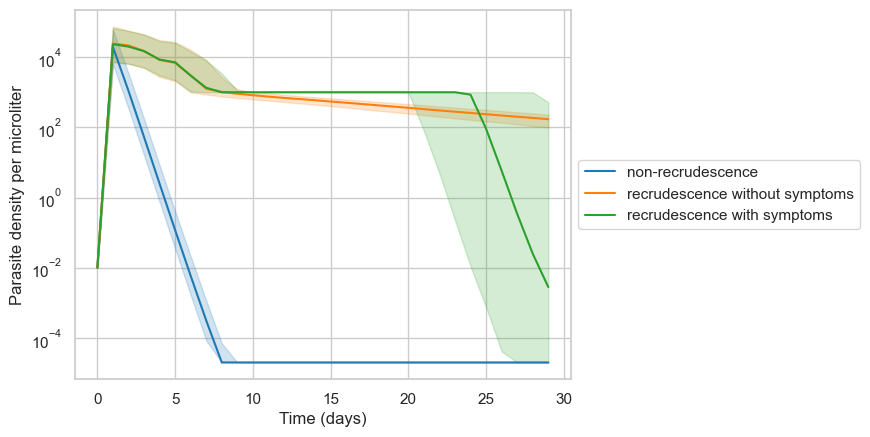

In [3]:
import seaborn as sns
import numpy as np

import seaborn as sns
import numpy as np

# Set the style for the plot
sns.set(style="whitegrid")

# Define the desired hue order
hue_order = ['non-recrudescence', 'recrudescence without symptoms', 'recrudescence with symptoms']

# Plot with lineplot, specifying the hue order
ax = sns.lineplot(data=processed_parasitaemia, 
                  x="time", 
                  y="parasitaemia", 
                  hue="recrudescence", 
                  hue_order=hue_order,  # Specify the order of hue categories
                  estimator=np.median, 
                  errorbar=lambda x: (np.quantile(x, 0.25), np.quantile(x, 0.75)),
                  palette="tab10")
# Set the legend outside of the plot
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# Set axis labels and log scale for y-axis
ax.set(xlabel='Time (days)', ylabel='Parasite density per microliter')
ax.set_yscale('log')

# Limit the x-axis to 28 days
# ax.set_xlim(0, 28)


In [4]:
non_recrudescence_df = processed_parasitaemia[(processed_parasitaemia['recrudescence'] == 'non-recrudescence') & (processed_parasitaemia['time'] == 0)]
non_recrudescence_df

,time,individual,recrudescence,parasitaemia
0,0,0,non-recrudescence,0.01
30,0,1,non-recrudescence,0.01
60,0,2,non-recrudescence,0.01
90,0,3,non-recrudescence,0.01
120,0,4,non-recrudescence,0.01
...,...,...,...,...
299880,0,9996,non-recrudescence,0.01
299940,0,9998,non-recrudescence,0.01
299970,0,9999,non-recrudescence,0.01
300000,0,10000,non-recrudescence,0.01


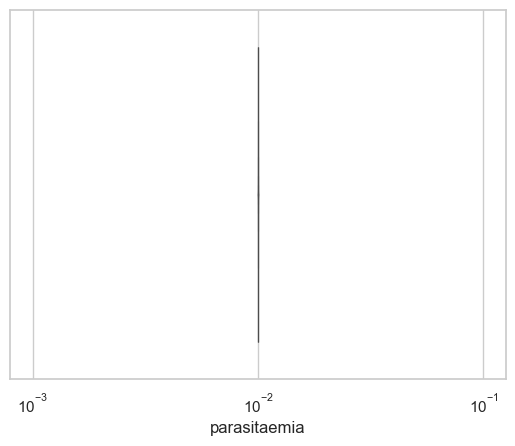

In [5]:
plot = sns.boxenplot(data=non_recrudescence_df, x='parasitaemia')
plot.set_xscale('log')

non-recrudescence
recrudescence without symptoms
recrudescence with symptoms


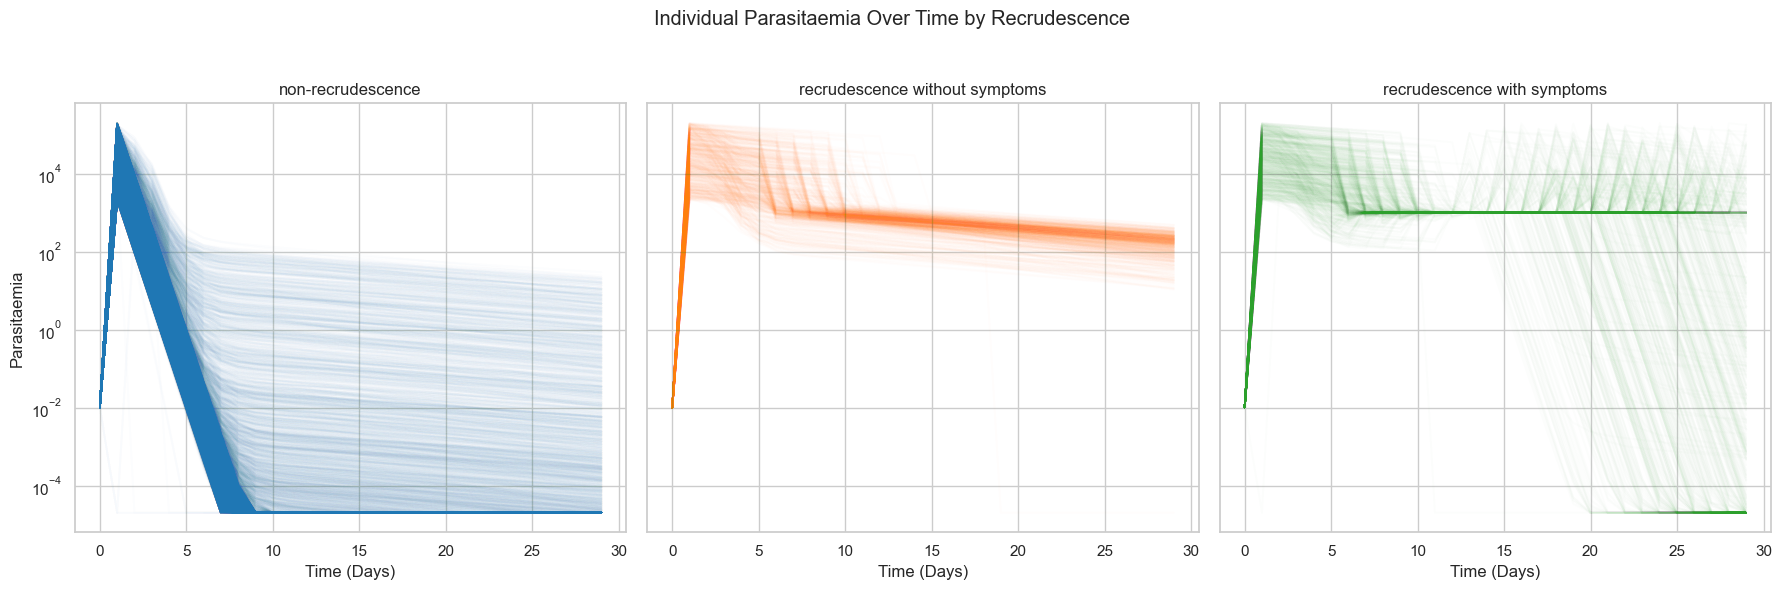

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Importing seaborn to use the tab10 color palette
import seaborn as sns

# Get the tab10 palette from seaborn
tab10_colors = sns.color_palette("tab10", 3)
# Define colors for each recrudescence type and their corresponding axes
recrudescence_types = ['non-recrudescence', 'recrudescence without symptoms', 'recrudescence with symptoms']

# Map recrudescence types to the tab10 colors
color_mapping = {
    'non-recrudescence': tab10_colors[0],  # Blueish
    'recrudescence without symptoms': tab10_colors[1],  # Orangish
    'recrudescence with symptoms': tab10_colors[2]  # Greenish
}

# Create subplots again with the updated data for each recrudescence group using tab10 colors
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, recrud_type in zip(axes, recrudescence_types):
    print(recrud_type)
    # Plot individual lines with light transparency
    for key, grp in processed_parasitaemia[processed_parasitaemia['recrudescence'] == recrud_type].groupby(['individual']):
        ax.plot(grp['time'], grp['parasitaemia'], color=color_mapping[recrud_type], alpha=0.01)
    
    # Plot the median line for the recrudescence type
    # median_data = processed_parasitaemia[processed_parasitaemia['recrudescence'] == recrud_type].groupby('time')['parasitaemia'].median()
    # ax.plot(median_data.index, median_data.values, color=color_mapping[recrud_type], linewidth=2.5, label=f'Median {recrud_type}')
    
    ax.set_title(recrud_type)
    ax.set_yscale('log')
    ax.set_xlabel('Time (Days)')
    ax.grid(True)
    
# Set the shared ylabel
axes[0].set_ylabel('Parasitaemia')

# Adjust layout and display the plot
plt.suptitle('Individual Parasitaemia Over Time by Recrudescence')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### AL

In [7]:
import pandas as pd 
import numpy as np


processed_parasitaemia = pd.read_csv("/Users/ktt/CLionProjects/malasim/cmake-build-release/bin/6_||||NY1||KTHFIMG,x||||||FNCMYRIPRPCRA|1_parasitaemia.csv")
# parasitaemia = pd.read_csv("6_0_parasitaemia.csv")
# remap recruitment number to a unique identifier
# 0 : non-recrudescence
# 1 : recrudescence without symptoms
# 2 : recrudescence with symptoms
processed_parasitaemia['recrudescence'] = processed_parasitaemia['recrudescence'].map({
    0: 'non-recrudescence',
    1: 'recrudescence without symptoms',
    2: 'recrudescence with symptoms'
})
processed_parasitaemia['parasitaemia'] = np.power(10, processed_parasitaemia['parasitaemia'])
# processed_parasitaemia['time'] = processed_parasitaemia['time'] -1


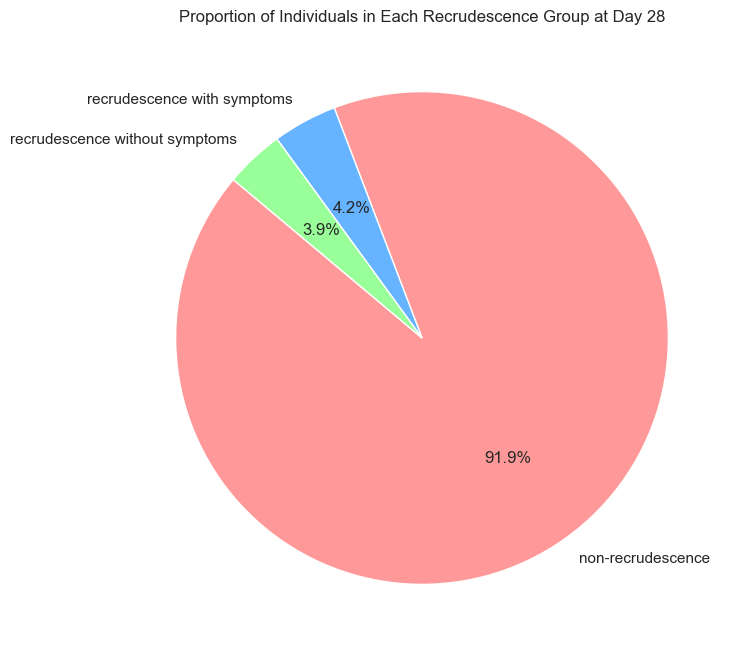

In [8]:
import matplotlib.pyplot as plt

# Filtering data for day 28
day_28_data = processed_parasitaemia[processed_parasitaemia['time'] == 28]
# Counting the number of individuals in each recrudescence group at day 28
group_counts = day_28_data['recrudescence'].value_counts()

# Plotting a pie chart for the distribution of individuals in each group
plt.figure(figsize=(8, 8))
plt.pie(group_counts, labels=group_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Proportion of Individuals in Each Recrudescence Group at Day 28')
plt.show()

In [9]:
# Filtering the non-recrudescence group at day 28
non_recrudescence_data = day_28_data[day_28_data['recrudescence'] == 'non-recrudescence']

# Counting the number of individuals with parasitaemia less than 2
count_less_than_2 = non_recrudescence_data[non_recrudescence_data['parasitaemia'] < 100].shape[0]
count_all = non_recrudescence_data.shape[0]
print("non_crecrudescence: %d, cured: %d"%(count_all, count_less_than_2))

print("Treatment success rate: %.2f%%"%(count_less_than_2/count_all*100))

non_crecrudescence: 9213, cured: 9213
Treatment success rate: 100.00%


# Recrudescence with symptoms

In [10]:
# Filtering the recrudescence with symptoms group
symptomatic_recrudescence_data = processed_parasitaemia[processed_parasitaemia['recrudescence'] == 'recrudescence with symptoms']
symptomatic_recrudescence_data = symptomatic_recrudescence_data[symptomatic_recrudescence_data['time'] > 14]
# Sorting the data by individual and time
symptomatic_recrudescence_data = symptomatic_recrudescence_data.sort_values(by=['individual', 'time'])

# Identifying the days and parasitaemia levels when there is an increase
increases = symptomatic_recrudescence_data.groupby('individual').apply(
    lambda group: group[(group['parasitaemia'].diff() > 0)]
).reset_index(drop=True)

# Collecting only the relevant columns: time and parasitaemia
increases_data = increases[['individual', 'time', 'parasitaemia']]

/var/folders/_1/qx5y40814xx23rbtxlb_kxsm0000gp/T/ipykernel_53504/691550836.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  increases = symptomatic_recrudescence_data.groupby('individual').apply(


Text(0.5, 1.0, 'Onset parasitaemia for recrudescence when symptoms appear')

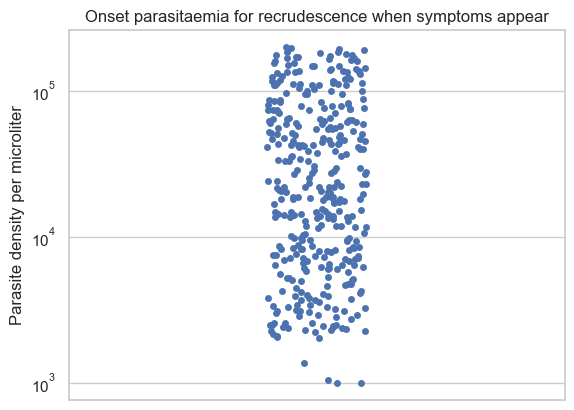

In [11]:
import seaborn as sns
ax = sns.stripplot(data= increases_data,y="parasitaemia")
ax.set_yscale('log')
ax.set(ylabel='Parasite density per microliter')
ax.set_title("Onset parasitaemia for recrudescence when symptoms appear")

a lot of 10^3 is due to randomness in time to End of Clinical (5-14) and time to develop symptom, random from (7, 54) days, which means symptoms not appear yet, as the simulation stop at day 28 

Text(0, 0.5, 'Day of symptom onset\nfor recrudescence with symptoms')

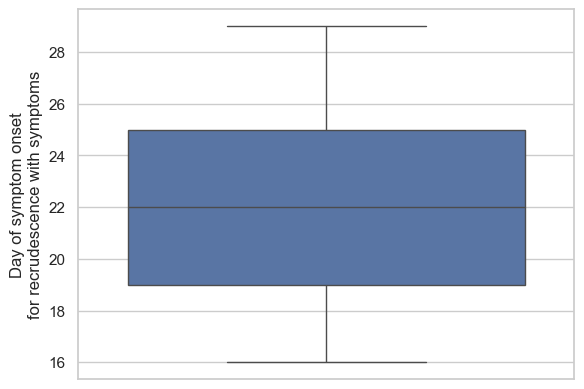

In [12]:
import seaborn as sns
ax = sns.boxplot(data= increases_data,y="time")
ax.set_ylabel("Day of symptom onset\nfor recrudescence with symptoms")

Text(0.5, 1.0, 'Parasitaemia before symptoms appear (end of clinical period)')

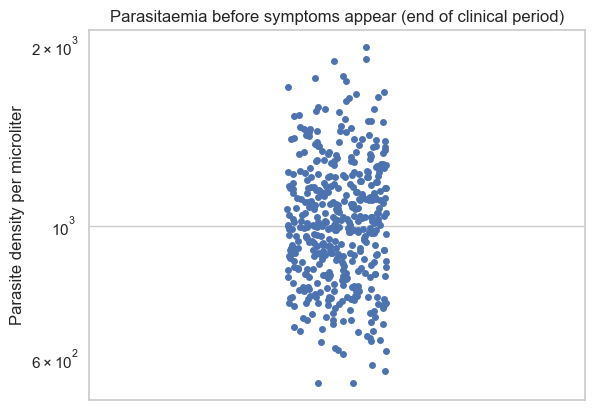

In [13]:
# Filtering the recrudescence with symptoms group
assymp_recrudescence_data = processed_parasitaemia[processed_parasitaemia['recrudescence'] == 'recrudescence with symptoms']
# assymp_recrudescence_data = assymp_recrudescence_data[assymp_recrudescence_data['time']> 6 ]
# Sorting the data by individual and time
assymp_recrudescence_data = assymp_recrudescence_data.sort_values(by=['individual', 'time'])

# get the first day of recrudescence and the parasitaemia level
first_day_recrudescence = assymp_recrudescence_data.groupby('individual').first()
first_day_recrudescence.reset_index(inplace=True)
first_day_recrudescence = first_day_recrudescence[first_day_recrudescence['time'] <14]

import seaborn as sns
ax = sns.stripplot(data=first_day_recrudescence,y="parasitaemia")
ax.set_yscale('log')
ax.set(ylabel='Parasite density per microliter')
ax.set_title("Parasitaemia before symptoms appear (end of clinical period)")

# Recrudescence without symptom

In [14]:
# Filtering the recrudescence with symptoms group
assymp_recrudescence_data = processed_parasitaemia[processed_parasitaemia['recrudescence'] == 'recrudescence without symptoms']
# assymp_recrudescence_data = assymp_recrudescence_data[assymp_recrudescence_data['time']> 6 ]
# Sorting the data by individual and time
assymp_recrudescence_data = assymp_recrudescence_data.sort_values(by=['individual', 'time'])

# get the first day of recrudescence and the parasitaemia level
first_day_recrudescence = assymp_recrudescence_data.groupby('individual').first()
first_day_recrudescence.reset_index(inplace=True)
first_day_recrudescence = first_day_recrudescence[first_day_recrudescence['time'] <14]


Text(0.5, 1.0, 'Parasitaemia of recrudescence without symptoms (end of clinical period)')

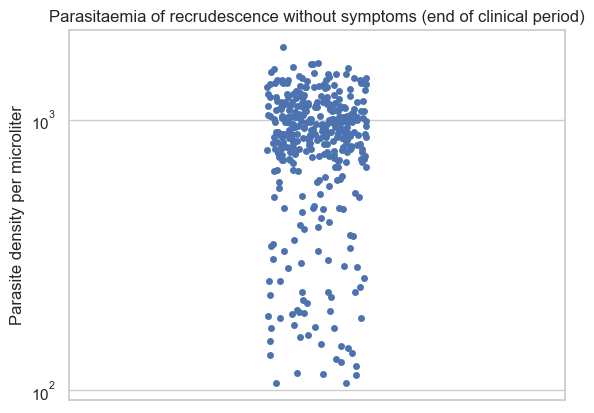

In [15]:
import seaborn as sns
ax = sns.stripplot(data=first_day_recrudescence,y="parasitaemia")
ax.set_yscale('log')
ax.set(ylabel='Parasite density per microliter')
ax.set_title("Parasitaemia of recrudescence without symptoms (end of clinical period)")